Train Model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from math import sqrt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import joblib
import os

# สร้างโฟลเดอร์ outputs หากยังไม่มี
os.makedirs('outputs', exist_ok=True)

# โหลดข้อมูล
df = pd.read_csv(r'C:\Work\CarAccident\dataset\cleandaily-all-years.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime').reset_index(drop=True)

# เลือกฟีเจอร์และ target
features = ['temperature_F', 'humidity_%', 'wind_speed_kmh', 'pressure_in']
targets = ['temperature_F', 'humidity_%', 'pressure_in']  # 3 outputs

print("📅 ช่วงเวลาข้อมูล:")
print(f"   ปี: {df['year'].min()} – {df['year'].max()}")
print(f"   จำนวนวันทั้งหมด: {len(df)}")

📅 ช่วงเวลาข้อมูล:
   ปี: 2020 – 2024
   จำนวนวันทั้งหมด: 1827


In [2]:
# แบ่ง train (2020–2023) และ test (2024)
df_train = df[df['year'] <= 2023].copy()
df_test = df[df['year'] == 2024].copy()

print(f"\n📊 แบ่งข้อมูล:")
print(f"   Train (2020–2023): {len(df_train)} วัน")
print(f"   Test  (2024)     : {len(df_test)} วัน")

# Normalize ทั้ง features และ targets ด้วย train เท่านั้น
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(df_train[features])
y_train_scaled = scaler_y.fit_transform(df_train[targets])

X_test_scaled = scaler_X.transform(df_test[features])
y_test_scaled = scaler_y.transform(df_test[targets])

# บันทึก scalers
joblib.dump(scaler_X, 'outputs/feature_scaler.pkl')
joblib.dump(scaler_y, 'outputs/target_scaler.pkl')


📊 แบ่งข้อมูล:
   Train (2020–2023): 1461 วัน
   Test  (2024)     : 366 วัน


['outputs/target_scaler.pkl']

In [3]:
n_steps = 30

def create_sequences(X, y, n_steps):
    X_seq, y_seq = [], []
    for i in range(len(X) - n_steps):
        X_seq.append(X[i:i+n_steps])
        y_seq.append(y[i+n_steps])  # ทำนายหลายค่าพร้อมกัน
    return np.array(X_seq), np.array(y_seq)

# Train
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, n_steps)

# Test: รวม 7 วันสุดท้ายของ train
last_n_train_X = X_train_scaled[-n_steps:]
last_n_train_y = y_train_scaled[-n_steps:]

combined_X_test = np.vstack([last_n_train_X, X_test_scaled])
combined_y_test = np.vstack([last_n_train_y, y_test_scaled])

X_test_seq, y_test_seq = create_sequences(combined_X_test, combined_y_test, n_steps)

print(f"\n🧮 ขนาดข้อมูล:")
print(f"   X_train: {X_train_seq.shape}, y_train: {y_train_seq.shape}")
print(f"   X_test:  {X_test_seq.shape}, y_test:  {y_test_seq.shape}")


🧮 ขนาดข้อมูล:
   X_train: (1431, 30, 4), y_train: (1431, 3)
   X_test:  (366, 30, 4), y_test:  (366, 3)


In [4]:
n_features = len(features)
n_outputs = len(targets)

model = Sequential([
    LSTM(128, activation='tanh', return_sequences=True, input_shape=(n_steps, n_features)),
    Dropout(0.2),
    LSTM(64, activation='tanh', return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(n_outputs)  # 3 outputs
])

model.compile(optimizer='adam', loss='mse')

print("\n🚀 เริ่มเทรนโมเดล...")
history = model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_test_seq, y_test_seq),
    epochs=50,
    batch_size=16,
    verbose=1
)

# บันทึกโมเดล
model.save('outputs/lstm_multivariate_2024.keras')
print("\n✅ บันทึกโมเดลเรียบร้อย!")


🚀 เริ่มเทรนโมเดล...
Epoch 1/50


c:\Work\CarAccident\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0732 - val_loss: 0.0238
Epoch 2/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0248 - val_loss: 0.0196
Epoch 3/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0228 - val_loss: 0.0184
Epoch 4/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0210 - val_loss: 0.0207
Epoch 5/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0205 - val_loss: 0.0211
Epoch 6/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0206 - val_loss: 0.0170
Epoch 7/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0195 - val_loss: 0.0181
Epoch 8/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0192 - val_loss: 0.0206
Epoch 9/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0192 - val_loss: 0.0177
Epoch 10/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0186 - val_loss: 0.0158
Epoch 11/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0180 - val_loss: 0.0185
Epoch 12/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0179 - val_l

In [5]:
# ทำนาย
y_pred_scaled = model.predict(X_test_seq, verbose=0)

# แปลงกลับเป็นค่าจริง
y_test_actual = scaler_y.inverse_transform(y_test_seq)
y_pred_actual = scaler_y.inverse_transform(y_pred_scaled)

# คำนวณเมตริกสำหรับแต่ละ target
results = {}
for i, target in enumerate(targets):
    rmse = sqrt(mean_squared_error(y_test_actual[:, i], y_pred_actual[:, i]))
    mae = mean_absolute_error(y_test_actual[:, i], y_pred_actual[:, i])
    mape = mean_absolute_percentage_error(y_test_actual[:, i], y_pred_actual[:, i])
    results[target] = {'RMSE': rmse, 'MAE': mae, 'MAPE': mape}
    print(f"\n📈 {target}:")
    print(f"   RMSE: {rmse:.4f}")
    print(f"   MAE:  {mae:.4f}")
    print(f"   MAPE: {mape:.4f} ({mape*100:.2f}%)")

# บันทึกผลเปรียบเทียบ
df_compare = pd.DataFrame({
    'date': df_test['datetime'].values,
    'actual_temperature_F': y_test_actual[:, 0],
    'predicted_temperature_F': y_pred_actual[:, 0],
    'actual_humidity_%': y_test_actual[:, 1],
    'predicted_humidity_%': y_pred_actual[:, 1],
    'actual_pressure_in': y_test_actual[:, 2],
    'predicted_pressure_in': y_pred_actual[:, 2],
})
df_compare.to_csv('outputs/2024_actual_vs_predicted.csv', index=False)
print("\n✅ บันทึกผลเปรียบเทียบ -> outputs/2024_actual_vs_predicted.csv")


📈 temperature_F:
   RMSE: 1.8909
   MAE:  1.5053
   MAPE: 0.0183 (1.83%)

📈 humidity_%:
   RMSE: 5.0198
   MAE:  4.0549
   MAPE: 0.0507 (5.07%)

📈 pressure_in:
   RMSE: 0.0508
   MAE:  0.0395
   MAPE: 0.0013 (0.13%)

✅ บันทึกผลเปรียบเทียบ -> outputs/2024_actual_vs_predicted.csv


Plot

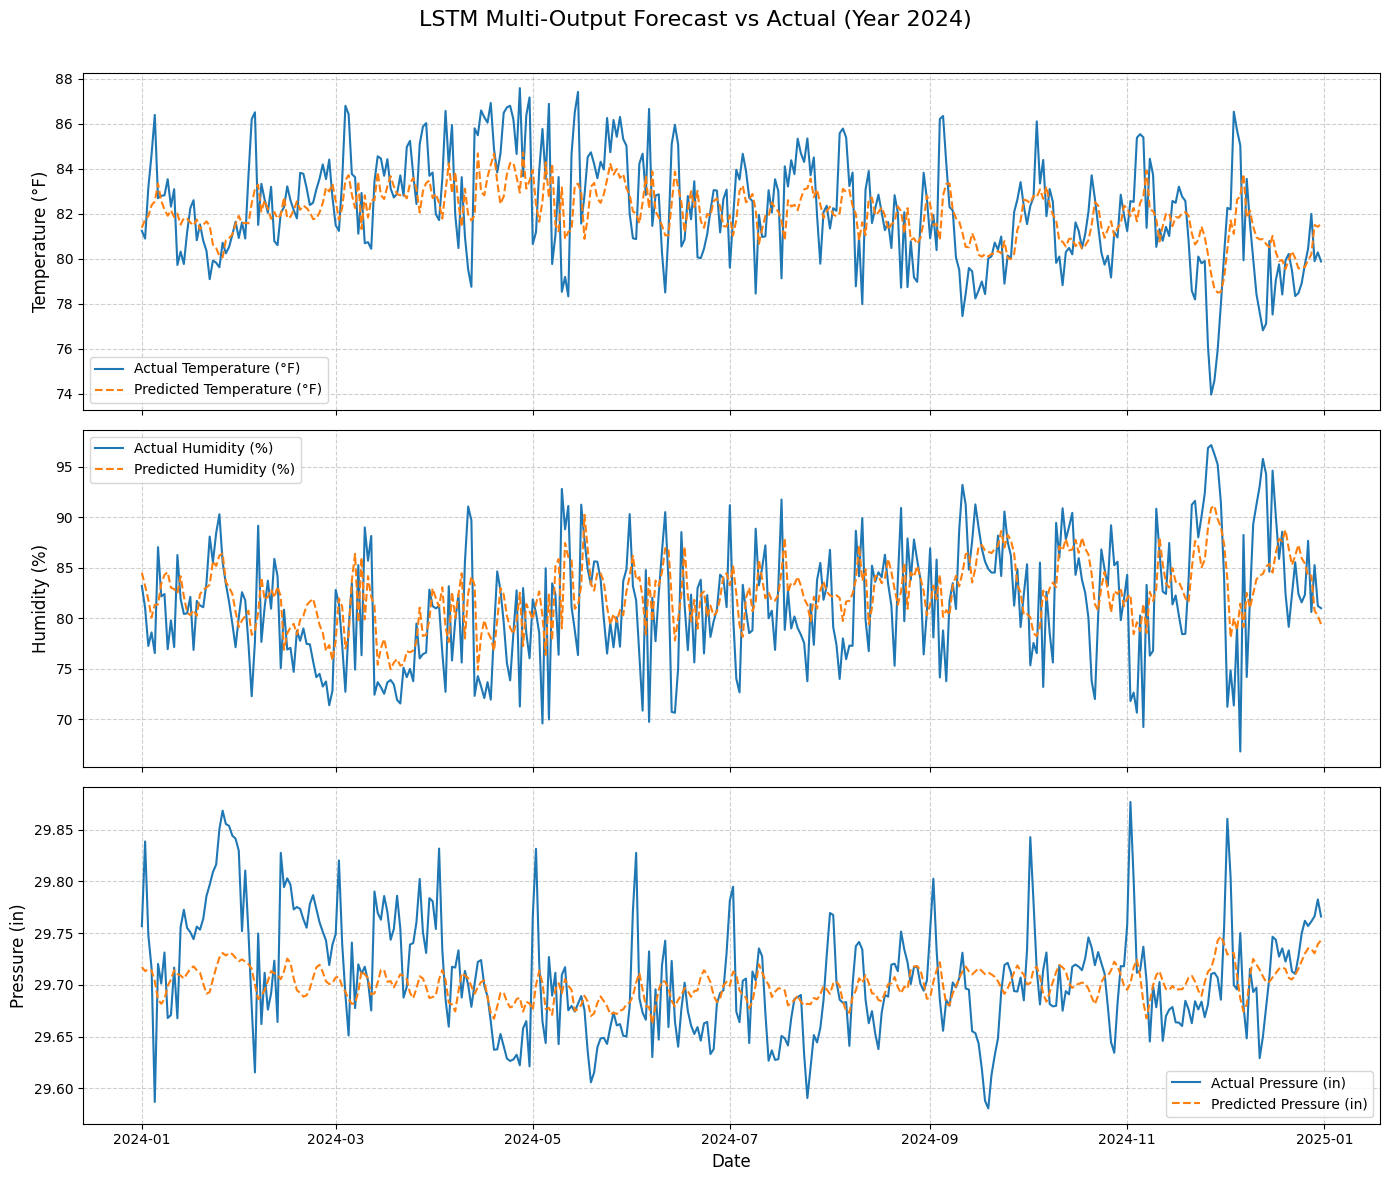

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# โหลดข้อมูลเปรียบเทียบ
df = pd.read_csv('outputs/2024_actual_vs_predicted.csv')
df['date'] = pd.to_datetime(df['date'])

# สร้างกราฟย่อย 3 ตัว
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

targets = [
    ('temperature_F', 'Temperature (°F)'),
    ('humidity_%', 'Humidity (%)'),
    ('pressure_in', 'Pressure (in)')
]

for i, (col, label) in enumerate(targets):
    axes[i].plot(df['date'], df[f'actual_{col}'], label=f'Actual {label}', color='tab:blue')
    axes[i].plot(df['date'], df[f'predicted_{col}'], label=f'Predicted {label}', color='tab:orange', linestyle='--')
    axes[i].set_ylabel(label, fontsize=12)
    axes[i].legend()
    axes[i].grid(True, linestyle='--', alpha=0.6)

axes[2].set_xlabel('Date', fontsize=12)
plt.suptitle('LSTM Multi-Output Forecast vs Actual (Year 2024)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()